# Import Library

In [64]:
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [65]:
# Pilihan:
# 0 = Full Dataset
# 1 = 10k
# 2 = 20k
# 3 = 30k
# 4 = 40k

CORPUS_SIZE = 0

if CORPUS_SIZE == 0:
    DATASET_NAME = "full"
elif CORPUS_SIZE == 1:
    DATASET_NAME = "10k"
elif CORPUS_SIZE == 2:
    DATASET_NAME = "20k"
elif CORPUS_SIZE == 3:
    DATASET_NAME = "30k"
elif CORPUS_SIZE == 4:
    DATASET_NAME = "40k"
else:
    raise ValueError(
        "CORPUS_SIZE harus 0, 1, 2, 3, atau 4"
    )

DATA_DIR = Path(
    f"dataset/preprocessed/{DATASET_NAME}"
)

print(f"Corpus : {DATASET_NAME}")
print(f"Path   : {DATA_DIR}")

Corpus : full
Path   : dataset\preprocessed\full


# Load Dataset & Label Encoder

Dataset

In [66]:
X_train = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/X_train.csv").squeeze()
X_test = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/X_test.csv").squeeze()

y_train = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/y_train.csv").squeeze()
y_test = pd.read_csv(f"dataset/preprocessed/{DATASET_NAME}/y_test.csv").squeeze()

Label Encoder

In [67]:
le = joblib.load("dataset/preprocessed/label_encoder.pkl")
class_names = list(le.classes_)

print(class_names)

['Economy', 'Entertainment', 'Technology']


c:\Users\HP 840 G6\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Vectorization

In [68]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=1,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(38963, 160673)
(9741, 160673)


In [69]:
os.makedirs("vectorizers/skenario 1", exist_ok=True)

joblib.dump(
    tfidf, 
    f"vectorizers/skenario 1/tfidf_vectorizer_{CORPUS_SIZE}.joblib"
)

['vectorizers/skenario 1/tfidf_vectorizer_0.joblib']

# Modeling

Training

In [70]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Predict

In [71]:
y_pred = nb_model.predict(X_test_tfidf)

In [72]:
os.makedirs("models/skenario 1", exist_ok=True)

joblib.dump(
    nb_model, 
    f"models/skenario 1/tfidf_nb_{CORPUS_SIZE}.joblib"
)

['models/skenario 1/tfidf_nb_0.joblib']

# Evaluation

## Confussion Matrix

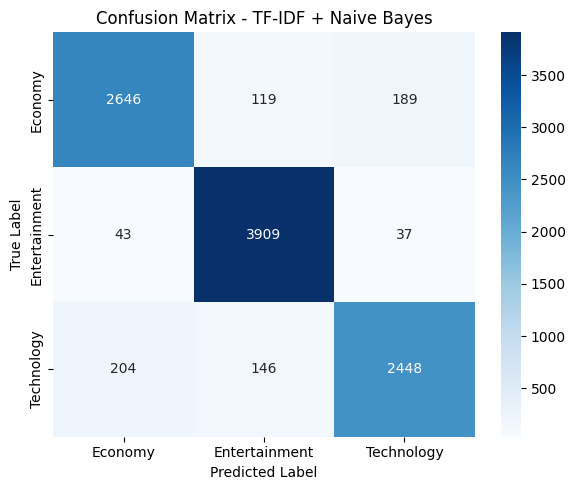

In [73]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - TF-IDF + Naive Bayes"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Classification Report

In [74]:
print("\n=== Classification Report ===\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


=== Classification Report ===

               precision    recall  f1-score   support

      Economy       0.91      0.90      0.91      2954
Entertainment       0.94      0.98      0.96      3989
   Technology       0.92      0.87      0.89      2798

     accuracy                           0.92      9741
    macro avg       0.92      0.92      0.92      9741
 weighted avg       0.92      0.92      0.92      9741



## Overall

In [75]:
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

rec = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n=== TF-IDF + Naive Bayes ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")


=== TF-IDF + Naive Bayes ===
Accuracy : 0.9242
Precision: 0.9222
Recall   : 0.9169
F1-Score : 0.9192


In [76]:
result = pd.DataFrame([
    {
        "Train_Size": len(X_train),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }
])

In [77]:
result

,Train_Size,Accuracy,Precision,Recall,F1-Score
0,38963,0.924238,0.922205,0.916863,0.919184


In [78]:
os.makedirs("results/traning", exist_ok=True)
RESULT_FILE = "results/traning/tfidf_nb_results.csv"

if os.path.exists(RESULT_FILE):
    previous = pd.read_csv(RESULT_FILE)

    result = pd.concat(
        [previous, result],
        ignore_index=True
    )

    # jika train size sama,
    # simpan hasil terbaru

    result = result.drop_duplicates(
        subset=["Train_Size"],
        keep="last"
    )

result = result.sort_values(by="Train_Size")
result.to_csv(RESULT_FILE, index=False)
